# Week 2 — Hubs survive. Clustering falls.

**Question:** Is the clustering of the Marvel Wikipedia network explained by its degrees alone?

Group exercise [2.11 on the actual 2026 Week 2 page](https://sunelehmann.com/socialgraphs2026-web/weeks/week2.html#go-nuts). This notebook executes our analysis script, rather than duplicating its implementation. Clone the full repository first; the notebook needs the frozen TSV inputs and the script. Install `requirements-week2-notebook.txt` into your notebook's Python environment. Running all cells regenerates 630 networks, the CSV, JSON and figure; allow a few minutes.

We choose average local clustering and the one-sided alternative **real > null** before generating simulations. Clustering is the fraction of neighbour-pairs that are linked, averaged equally across nodes (degree < 2 contributes zero). A node with four neighbours and three links among them has local clustering 3/6 = 0.5. This is not the pooled triangle measure, transitivity.

In [1]:
from pathlib import Path
import json, runpy, statistics
from IPython.display import display, Markdown, Image

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts/analyze_week2.py').is_file())
analysis = runpy.run_path(str(ROOT / 'scripts/analyze_week2.py'))
g = analysis['load']()
print(f'Fixed original giant component: {len(g)} nodes, {g.number_of_edges()} undirected links')
print('Real statistics:', analysis['measure'](g))


Matplotlib is building the font cache; this may take a moment.


Fixed original giant component: 277 nodes, 1421 undirected links
Real statistics: {'clustering': 0.31994695803394674, 'transitivity': 0.18228476821192052, 'triangles': 1835, 'edges': 1421, 'max_degree': 106, 'components': 1}


## What each baseline keeps

1. **Random links:** G(n,m), with the exact same 277 nodes and 1,421 links, but unconstrained degrees.
2. **Edge swaps:** retain each node's degree exactly. Each run starts from the real graph, with 10 × 1,421 successful swaps. Reject duplicate links and self-links.
3. **Configuration model, simplified:** random stub pairing initially preserves degrees; removing self-links and collapsing duplicate links does not. This is a diagnostic comparison, not an exact degree-preserving null.

There are 200 runs of each, plus 30 sensitivity runs at 50 × 1,421 successful edge swaps. Master seed: 280502; each run gets its own saved seed. All 277 original nodes remain in each null, even if a null becomes disconnected. There is no connectivity constraint and we do not reselect a giant component.

The full original roster has 303 characters, including 17 isolates, and is loaded before the 1,784 directed edges. Converting to undirected gives 1,434 links; selecting the original giant component deliberately excludes 26 nodes. These source files are the course's 26 August 2026 frozen snapshot; their SHA-256 hashes are saved in the results.

In [2]:
# Runs the actual simulation; overwrites only generated Week 2 result files.
analysis['main']()
results = json.loads((ROOT / 'data/week2/results.json').read_text())


Completed random: 200 networks


Completed swapped: 200 networks


Completed configuration: 200 networks


Completed long_swapped: 30 networks


{
  "n": 277,
  "m": 1421,
  "real": {
    "clustering": 0.31994695803394674,
    "transitivity": 0.18228476821192052,
    "triangles": 1835,
    "edges": 1421,
    "max_degree": 106,
    "components": 1
  },
  "models": {
    "random": {
      "runs": 200,
      "mean": 0.037108973712502664,
      "sd": 0.0031405039433872097,
      "z": 90.06133710387495,
      "exceedances": 0,
      "p_upper": 0.004975124378109453,
      "mean_edges_lost": 0,
      "mean_hub_degree": 10.08,
      "mean_transitivity": 0.0371353519194316
    },
    "swapped": {
      "runs": 200,
      "mean": 0.15580105163879765,
      "sd": 0.009285215542146272,
      "z": 17.67820096906516,
      "exceedances": 0,
      "p_upper": 0.004975124378109453,
      "mean_edges_lost": 0,
      "mean_hub_degree": 106,
      "mean_transitivity": 0.11776291390728477
    },
    "configuration": {
      "runs": 200,
      "mean": 0.11070159374818948,
      "sd": 0.008532972864659203,
      "z": 24.521976994956052,
      "exceed

| Model | Runs | Mean C | SD | z (descriptive) | Exceedances | Corrected p | Mean edges lost | Original hub mean degree |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| random | 200 | 0.03711 | 0.00314 | 90.06 | 0 | 0.00498 | 0.00 | 10.08 |
| swapped | 200 | 0.15580 | 0.00929 | 17.68 | 0 | 0.00498 | 0.00 | 106.00 |
| configuration | 200 | 0.11070 | 0.00853 | 24.52 | 0 | 0.00498 | 103.35 | 76.83 |
| long_swapped | 30 | 0.15351 | 0.00910 | 18.28 | 0 | 0.03226 | 0.00 | 106.00 |


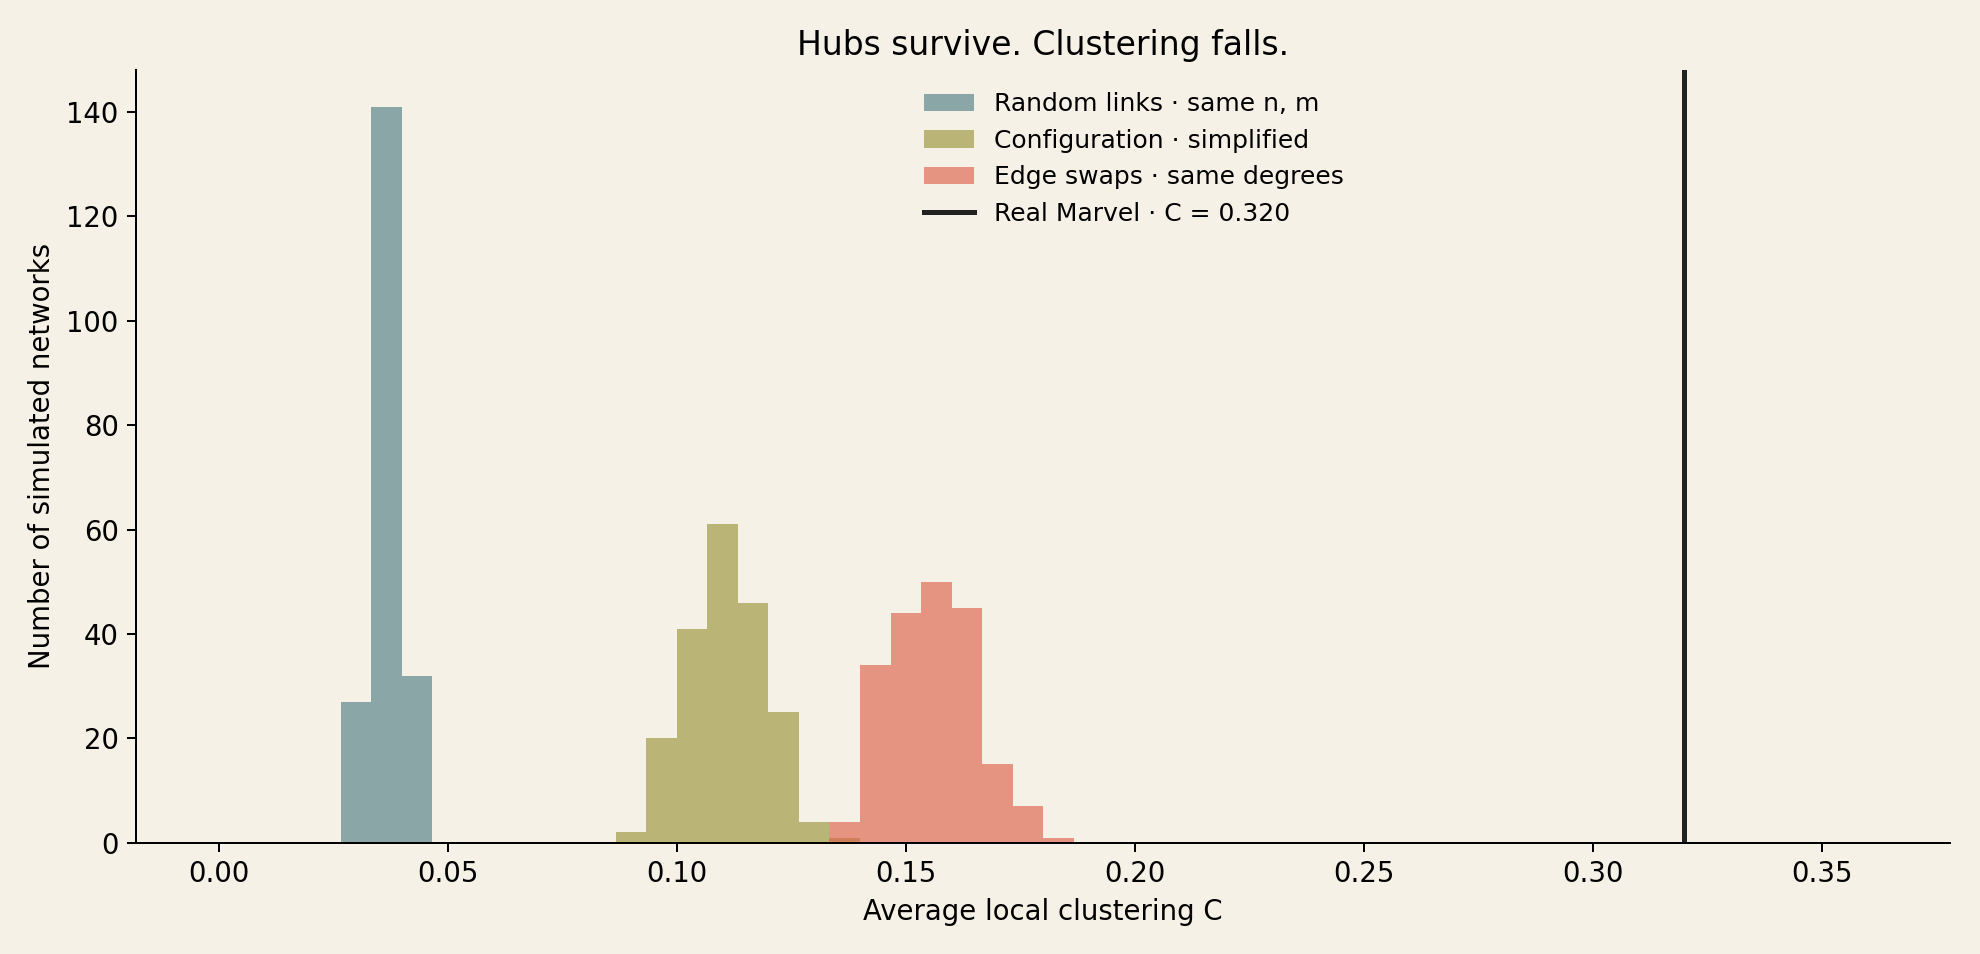

In [3]:
table = '| Model | Runs | Mean C | SD | z (descriptive) | Exceedances | Corrected p | Mean edges lost | Original hub mean degree |\n'
table += '|---|---:|---:|---:|---:|---:|---:|---:|---:|\n'
for name, m in results['models'].items():
    table += f"| {name} | {m['runs']} | {m['mean']:.5f} | {m['sd']:.5f} | {m['z']:.2f} | {m['exceedances']} | {m['p_upper']:.5f} | {m['mean_edges_lost']:.2f} | {m['mean_hub_degree']:.2f} |\n"
display(Markdown(table))
display(Image(filename=str(ROOT / 'weeks/week2/clustering_nulls.png')))


In [4]:
import csv, hashlib, math
rows = list(csv.DictReader((ROOT / 'data/week2/samples.csv').open()))
assert len(rows) == 630
for name, model in results['models'].items():
    values = [float(r['clustering']) for r in rows if r['model'] == name]
    assert len(values) == model['runs']
    assert math.isclose(statistics.mean(values), model['mean'])
    exceed = sum(v >= results['real']['clustering'] for v in values)
    assert model['p_upper'] == (1 + exceed) / (1 + len(values))
for filename, expected in results['source_sha256'].items():
    assert hashlib.sha256((ROOT / 'data/week1' / filename).read_bytes()).hexdigest() == expected
print('All 630 rows agree with the summary; source-file hashes match.')
print('Software versions:', results['versions'])


All 630 rows agree with the summary; source-file hashes match.
Software versions: {'python': '3.12.12', 'networkx': '3.5', 'numpy': '2.2.6', 'matplotlib': '3.10.6'}


## Read the result, not just the p-value

The histogram's x-axis is **one whole network's average clustering**; bar heights count simulated networks in each interval. Each colour contains 200 runs. The black line is the real network, not another distribution. The degree-preserving distribution is centred near 0.156, well below real C ≈ 0.320. Real clustering is about 2.05 times the main null mean. Keeping the hubs is not enough to reproduce it.

No main shuffle reaches real C. The corrected one-sided empirical p-value is **1/201 ≈ 0.00498**, never zero. It is limited by simulation count and assumes adequate randomisation. z ≈ 17.68 is descriptive; we do not infer a normal-tail probability or a probability that the null is true. The 30 longer runs average ≈ 0.15351 (SD ≈ 0.00910), supporting the qualitative result but not proving complete mixing. Other recorded measures (triangles, transitivity, components) are descriptive, not additional selected significance tests.

**Surprise:** simplifying the configuration model removes about 103.35 links per run and reduces the original 106-degree hub to about 76.83 neighbours on average. A model labelled 'same degrees' would be misleading after that cleanup.

**Limits:** links are Wikipedia hyperlinks, not friendships. Direction and the smaller components are outside this question. Team membership, shared storylines and editorial practice are plausible explanations, but this test does not establish any of them as the cause. Differences between model means are not a causal decomposition. Next: inspect triangle-rich neighbourhoods and test a model that also preserves independently defined team memberships.

AI assistance: Codex helped formulate the analysis, implement and execute it, and draft the explanation. Inspect `scripts/analyze_week2.py` for the full implementation; all raw simulation outputs are in `data/week2/samples.csv`.